# House Price Prediction using ML #

In this notebok, the code of the project is being presented in small readable sections. For more information about the project, please refer to the written report.

____________________________________________________________________________________________________________________________________________________________________________________________________________________________________

### Imports ###

Firstly, all the necessary libraries are imported.

In [19]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, random_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

____________________________________________________________________________________________________________________________________________________________________________________________________________________________________

### Dataset ###

The downloaded file "train.csv" is used as the dataset for training and validation of the ML model. 

In the first line, the correct file path need to be specified. Otherwise, the code will not be working as the path provided here is for my laptop.

In [20]:
train = pd.read_csv("C:/Users/jimka/Desktop/train.csv")
train_id = train['Id']
train = train.drop('Id', axis=1)

Before the data is processed, it is important to seperate the numerical data from the string-based ones. The latter is tranformed to numerical via one-hot encoding.

Z-score normalization is also applied:

   $ x' = (x- μ) / σ $ , where $ μ$= mean and $σ $= std

In [21]:
numeric_cols = train.select_dtypes(include=["int64","float64"]).columns
numeric_cols = numeric_cols.drop("SalePrice")
categorical_cols = train.select_dtypes(include=["object"]).columns

train[numeric_cols] = train[numeric_cols].fillna(train[numeric_cols].mean())
train[categorical_cols] = train[categorical_cols].fillna("None")
train = pd.get_dummies(train)

# Extract target and features
y = train["SalePrice"].values
X = train.drop("SalePrice", axis=1).values

# Scale features and target
scaler_X = StandardScaler()
X = scaler_X.fit_transform(X)
scaler_y = StandardScaler()
y = scaler_y.fit_transform(y.reshape(-1,1))

NumPy arrays are then converted to PyTorch tensors.

In [22]:

X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32).view(-1,1)

20 % of data will be used for validation, whereas the rest for the model training.

In [23]:
val_ratio = 0.2
val_size = int(len(X_tensor) * val_ratio)
train_size = len(X_tensor) - val_size

train_dataset, val_dataset = random_split(TensorDataset(X_tensor, y_tensor), [train_size, val_size])
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)

____________________________________________________________________________________________________________________________________________________________________________________________________________________________________

### Model Training ###

A feedforward neural network for regression is defined. 

In [24]:
class HousePriceModel(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 1)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)

model = HousePriceModel(X_tensor.shape[1])


The function computes Mean Absolute Error (MAE), in order to mesure the absolute difference between prediction and target. MAE is more robust to outliers than MSE.

$L = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|$

The optimizer used is Adam and the initial step size for parameter updates is set to 0.001

In [25]:
criterion = nn.L1Loss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

The number of epochs is initially equal to 200 but this variable can always change. The model's predictions are compared with the true labels using the MAE loss function.

In [26]:
epochs = 200
for epoch in range(epochs):
    model.train()
    epoch_loss = 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        preds = model(X_batch)
        loss = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss/len(train_loader):.4f}")

Epoch 1/200, Loss: 0.3924
Epoch 2/200, Loss: 0.2028
Epoch 3/200, Loss: 0.1638
Epoch 4/200, Loss: 0.1432
Epoch 5/200, Loss: 0.1258
Epoch 6/200, Loss: 0.1212
Epoch 7/200, Loss: 0.1131
Epoch 8/200, Loss: 0.1117
Epoch 9/200, Loss: 0.1011
Epoch 10/200, Loss: 0.0999
Epoch 11/200, Loss: 0.0941
Epoch 12/200, Loss: 0.0951
Epoch 13/200, Loss: 0.0879
Epoch 14/200, Loss: 0.0926
Epoch 15/200, Loss: 0.0815
Epoch 16/200, Loss: 0.0765
Epoch 17/200, Loss: 0.0851
Epoch 18/200, Loss: 0.0795
Epoch 19/200, Loss: 0.0758
Epoch 20/200, Loss: 0.0697
Epoch 21/200, Loss: 0.0677
Epoch 22/200, Loss: 0.0703
Epoch 23/200, Loss: 0.0660
Epoch 24/200, Loss: 0.0653
Epoch 25/200, Loss: 0.0622
Epoch 26/200, Loss: 0.0629
Epoch 27/200, Loss: 0.0593
Epoch 28/200, Loss: 0.0619
Epoch 29/200, Loss: 0.0639
Epoch 30/200, Loss: 0.0700
Epoch 31/200, Loss: 0.0592
Epoch 32/200, Loss: 0.0570
Epoch 33/200, Loss: 0.0579
Epoch 34/200, Loss: 0.0576
Epoch 35/200, Loss: 0.0571
Epoch 36/200, Loss: 0.0528
Epoch 37/200, Loss: 0.0538
Epoch 38/2

The model is then switched to evaluation mode and the scaling is reversed.

In [27]:
model.eval()
val_preds_list = []
val_actual_list = []

with torch.no_grad():
    for X_val, y_val in val_loader:
        preds = model(X_val)
        val_preds_list.append(preds)
        val_actual_list.append(y_val)

val_preds = torch.cat(val_preds_list).numpy()
val_actual = torch.cat(val_actual_list).numpy()

# Reverse scaling
val_preds_prices = scaler_y.inverse_transform(val_preds)
val_actual_prices = scaler_y.inverse_transform(val_actual)

____________________________________________________________________________________________________________________________________________________________________________________________________________________________________

### Visualisation ###

The Sale Prices are then distributed into 3 categories:

Low, for prices up to 150k

Medium, for prices between  150k and 300k

High, for prices more than 300k

In [28]:
bins = [0, 150000, 300000, np.inf]
labels = [0,1,2]
val_actual_class = np.digitize(val_actual_prices, bins) - 1
val_pred_class   = np.digitize(val_preds_prices, bins) - 1
class_names = ["Low","Medium","High"]

A standard and a normalized confusion matrix are computed. In the normalized matrix, accuracy per class is represented, which helps compare classes with unequal samples.

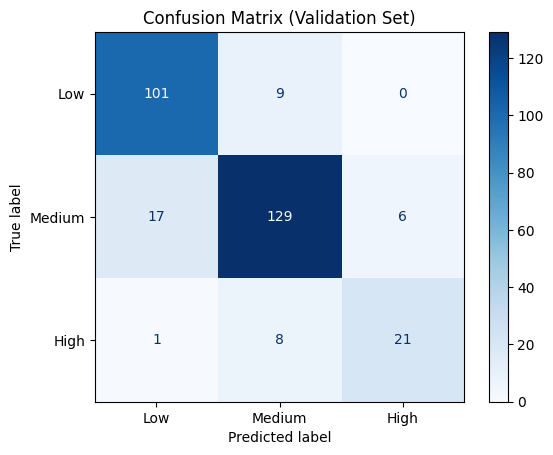

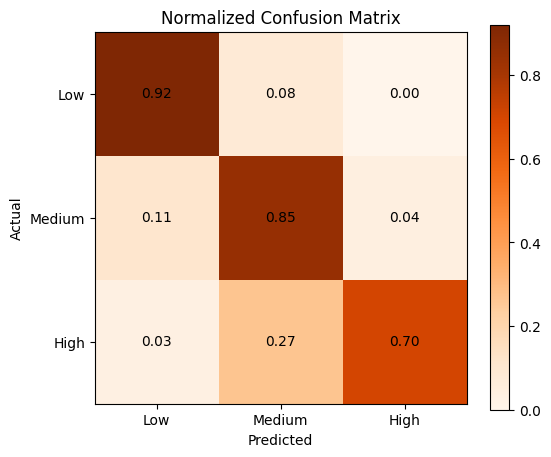

In [29]:

# Standard confusion matrix
cm = confusion_matrix(val_actual_class, val_pred_class, labels=[0,1,2])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix (Validation Set)")
plt.show()

# Normalized confusion matrix
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
plt.figure(figsize=(6,5))
plt.imshow(cm_normalized, interpolation='nearest', cmap=plt.cm.Oranges)
plt.title("Normalized Confusion Matrix")
plt.colorbar()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)
plt.ylabel('Actual')
plt.xlabel('Predicted')
for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(j, i, f"{cm_normalized[i,j]:.2f}", ha="center", va="center", color="black")
plt.show()

The misclassification bar plot shows which class had the most errors.

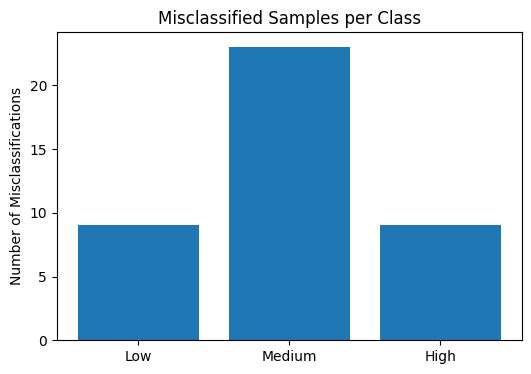

In [30]:
# Misclassification bar plot
misclassified = cm.sum(axis=1) - np.diag(cm)
plt.figure(figsize=(6,4))
plt.bar(class_names, misclassified)
plt.ylabel("Number of Misclassifications")
plt.title("Misclassified Samples per Class")
plt.show()

Within the classification report, some metrics are printed per class, for instance how many predicted as this class were correct, how many actual samples of this class were correctly predicted, the harmonic mean of the two former values and number of samples per class.

In [31]:
# Classification report
report = classification_report(val_actual_class, val_pred_class, target_names=class_names)
print("Classification Report:\n", report)

Classification Report:
               precision    recall  f1-score   support

         Low       0.85      0.92      0.88       110
      Medium       0.88      0.85      0.87       152
        High       0.78      0.70      0.74        30

    accuracy                           0.86       292
   macro avg       0.84      0.82      0.83       292
weighted avg       0.86      0.86      0.86       292



A more detailed confusion- style  matrix is created which shows how many houses in a given actual price range were predicted in that price range. There are 8 rows (actual price range) and 8 columns (predicted price range)

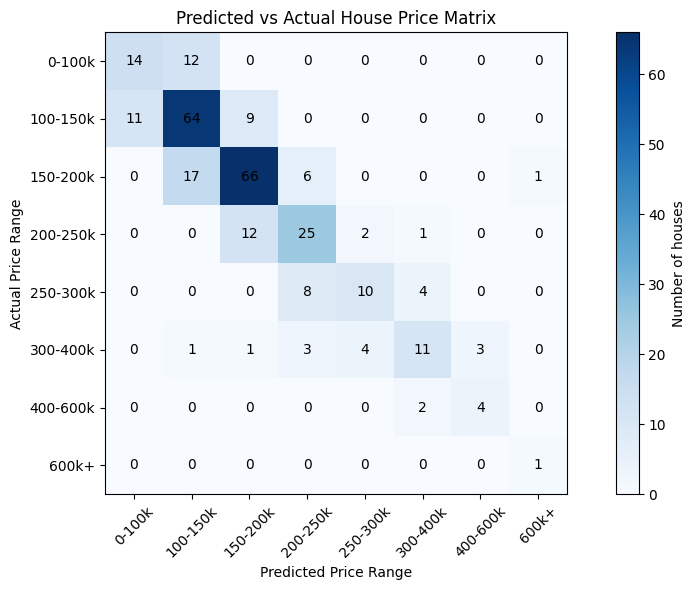

In [32]:
price_bins = [0, 100000, 150000, 200000, 250000, 300000, 400000, 600000, np.inf]
bin_labels = ["0-100k","100-150k","150-200k","200-250k","250-300k","300-400k","400-600k","600k+"]

actual_bins = np.digitize(val_actual_prices.flatten(), price_bins) - 1
pred_bins   = np.digitize(val_preds_prices.flatten(), price_bins) - 1

matrix_size = len(price_bins) - 1
price_matrix = np.zeros((matrix_size, matrix_size), dtype=int)

for a,p in zip(actual_bins, pred_bins):
    price_matrix[a,p] += 1

plt.figure(figsize=(10,6))
plt.imshow(price_matrix, cmap="Blues")
plt.colorbar(label="Number of houses")
plt.xticks(ticks=np.arange(matrix_size), labels=bin_labels, rotation=45)
plt.yticks(ticks=np.arange(matrix_size), labels=bin_labels)
plt.xlabel("Predicted Price Range")
plt.ylabel("Actual Price Range")
plt.title("Predicted vs Actual House Price Matrix")
for i in range(matrix_size):
    for j in range(matrix_size):
        plt.text(j,i, price_matrix[i,j], ha="center", va="center", color="black")
plt.tight_layout()
plt.show()

Finally, there is also a scatter plot available for evaluation. The diagonal line is the perfect prediction line and the scatter points should be as closer to the diagonal as possible for the model to function satisfactorily.

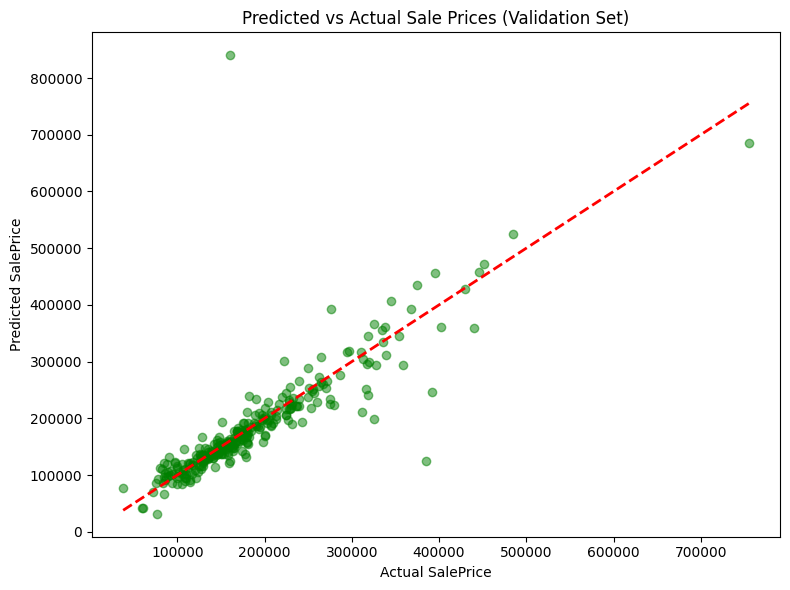

In [33]:
plt.figure(figsize=(8,6))
plt.scatter(val_actual_prices, val_preds_prices, alpha=0.5, color='green')
plt.plot([val_actual_prices.min(), val_actual_prices.max()],
         [val_actual_prices.min(), val_actual_prices.max()],
         color='red', linestyle='--', linewidth=2)  # y = x line
plt.xlabel("Actual SalePrice")
plt.ylabel("Predicted SalePrice")
plt.title("Predicted vs Actual Sale Prices (Validation Set)")
plt.tight_layout()
plt.show()

____________________________________________________________________________________________________________________________________________________________________________________________________________________________________

### Results ###

As deducted from the confusion matrices above, most houses in the Low price range were correctly predicted, with a percentage of 92 %. 

The model also managed to predicted correctly 85% of the Medium price houses.

Most errors occured for the expensive properties, mainly due to the data shortage for that price range. 70 % of High priced houses were correctly predicted, whereas 27% were wrongly predicted as Medium priced.

As shown in the larger confusion matrix with the price ranges, the diagonal stands out indeed, which means that the model mostly achieves its goal. On most cases, if a house is misclassified, it is placed within the adjacent price ranges, which means that the difference is only 50-100k from the real price.

The scatter plot validates that most properties that cost between 100k-250k are correctly classified, whereas for prices more than 400k there are outliers.

____________________________________________________________________________________________________________________________________________________________________________________________________________________________________

### Model test  ###

There is another file called "test.csv" inside the downloaded folder from Kaggle. This file can be used, given that the model works adequately well, in order to predict the prices for some houses.

There are new house values provided, but there is no Sale Price. The ML model is used for this goal.

In [34]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# -----------------------------
# 1. Load datasets
# -----------------------------
train = pd.read_csv("C:/Users/jimka/Desktop/train.csv")
test = pd.read_csv("C:/Users/jimka/Desktop/test.csv")

train_id = train["Id"]
test_id = test["Id"]

train = train.drop("Id", axis=1)
test = test.drop("Id", axis=1)

# -----------------------------
# 2. Separate target
# -----------------------------
y_train = train["SalePrice"]
train = train.drop("SalePrice", axis=1)

# -----------------------------
# 3. Combine datasets for preprocessing
# -----------------------------
full_data = pd.concat([train, test], axis=0)

# -----------------------------
# 4. Handle missing values
# -----------------------------
numeric_cols = full_data.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = full_data.select_dtypes(include=["object"]).columns

full_data[numeric_cols] = full_data[numeric_cols].fillna(full_data[numeric_cols].mean())
full_data[categorical_cols] = full_data[categorical_cols].fillna("None")

# -----------------------------
# 5. Convert categorical variables
# -----------------------------
full_data = pd.get_dummies(full_data)

# -----------------------------
# 6. Split data back
# -----------------------------
X_train = full_data.iloc[:len(train), :]
X_test = full_data.iloc[len(train):, :]

# -----------------------------
# 7. Feature scaling
# -----------------------------
scaler_X = StandardScaler()

X_train = scaler_X.fit_transform(X_train)
X_test = scaler_X.transform(X_test)

scaler_y = StandardScaler()
y_train = scaler_y.fit_transform(y_train.values.reshape(-1,1))

# -----------------------------
# 8. Convert to tensors
# -----------------------------
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

# -----------------------------
# 9. Define neural network
# -----------------------------
class HousePriceModel(nn.Module):

    def __init__(self, input_size):
        super().__init__()

        self.fc1 = nn.Linear(input_size,128)
        self.fc2 = nn.Linear(128,64)
        self.fc3 = nn.Linear(64,1)

    def forward(self,x):

        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)

        return x


model = HousePriceModel(X_train.shape[1])

# -----------------------------
# 10. Training setup
# -----------------------------
criterion = nn.L1Loss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epochs = 200

# -----------------------------
# 11. Train model
# -----------------------------
for epoch in range(epochs):

    total_loss = 0

    for X_batch, y_batch in train_loader:

        optimizer.zero_grad()

        predictions = model(X_batch)

        loss = criterion(predictions, y_batch)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss/len(train_loader):.4f}")

# -----------------------------
# 12. Predict test data
# -----------------------------
model.eval()

with torch.no_grad():

    test_predictions = model(X_test_tensor)

test_predictions = test_predictions.numpy()

# convert back to real prices
test_predictions = scaler_y.inverse_transform(test_predictions)

# -----------------------------
# 13. Create submission file
# -----------------------------
submission = pd.DataFrame({
    "Id": test_id,
    "SalePrice": test_predictions.flatten()
})

submission.to_csv("submission.csv", index=False)

print("Predictions saved to submission.csv")

# -----------------------------
# 14. Optional visualization
# -----------------------------
# if SalePrice exists in test set

if "SalePrice" in test.columns:

    actual_prices = test["SalePrice"].values
    predicted_prices = test_predictions.flatten()

    plt.figure(figsize=(8,6))

    plt.scatter(actual_prices, predicted_prices, alpha=0.5)

    plt.plot([actual_prices.min(), actual_prices.max()],
             [actual_prices.min(), actual_prices.max()],
             color="red", linestyle="--")

    plt.xlabel("Actual Price")
    plt.ylabel("Predicted Price")
    plt.title("Actual vs Predicted House Prices")

    plt.show()

Epoch 1/200, Loss: 0.3706
Epoch 2/200, Loss: 0.2040
Epoch 3/200, Loss: 0.1750
Epoch 4/200, Loss: 0.1573
Epoch 5/200, Loss: 0.1458
Epoch 6/200, Loss: 0.1324
Epoch 7/200, Loss: 0.1253
Epoch 8/200, Loss: 0.1174
Epoch 9/200, Loss: 0.1072
Epoch 10/200, Loss: 0.1078
Epoch 11/200, Loss: 0.0997
Epoch 12/200, Loss: 0.1000
Epoch 13/200, Loss: 0.1000
Epoch 14/200, Loss: 0.0986
Epoch 15/200, Loss: 0.0960
Epoch 16/200, Loss: 0.0907
Epoch 17/200, Loss: 0.0862
Epoch 18/200, Loss: 0.0825
Epoch 19/200, Loss: 0.0833
Epoch 20/200, Loss: 0.0810
Epoch 21/200, Loss: 0.0781
Epoch 22/200, Loss: 0.0729
Epoch 23/200, Loss: 0.0757
Epoch 24/200, Loss: 0.0733
Epoch 25/200, Loss: 0.0782
Epoch 26/200, Loss: 0.0731
Epoch 27/200, Loss: 0.0705
Epoch 28/200, Loss: 0.0690
Epoch 29/200, Loss: 0.0701
Epoch 30/200, Loss: 0.0660
Epoch 31/200, Loss: 0.0707
Epoch 32/200, Loss: 0.0647
Epoch 33/200, Loss: 0.0613
Epoch 34/200, Loss: 0.0660
Epoch 35/200, Loss: 0.0613
Epoch 36/200, Loss: 0.0611
Epoch 37/200, Loss: 0.0607
Epoch 38/2

The results are saved inside a new file called "submission.csv". The first few rows will be displayed as follows:

In [36]:
import pandas as pd

# Load CSV into a DataFrame
df = pd.read_csv("C:/Users/jimka/Desktop/submission.csv")

# Display the first few rows
df.head()

,Id,SalePrice
0,1461,131653.77
1,1462,163465.77
2,1463,187523.90
3,1464,200386.44
4,1465,184340.45
